In [1]:
import pandas as pd
import numpy as np

## 1.Ingesta de datos

In [2]:

paths = {
    2024:   "contaminantes_2024.csv",
    2025:   "contaminantes_2025.csv",
    2026:   "contaminantes_2026.csv",
}

In [3]:
def leer_contaminantes(path, year):
    df = pd.read_csv(path, skiprows=9, low_memory=False)

    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
    )

    df = df.rename(columns={"value": "valor"})
    df["year_archivo"] = year

    return df

In [4]:
df_raw = pd.concat(
    [leer_contaminantes(path, year) for year, path in paths.items()],
    ignore_index=True
)

df_raw.head()

,date,id_station,id_parameter,valor,unit,year_archivo
0,2024-01-01 01:00:00,ACO,CO,NaN,15.0,2024
1,2024-01-01 01:00:00,ACO,NO,NaN,1.0,2024
2,2024-01-01 01:00:00,ACO,NO2,NaN,1.0,2024
3,2024-01-01 01:00:00,ACO,NOX,NaN,1.0,2024
4,2024-01-01 01:00:00,ACO,O3,NaN,1.0,2024


## 2. Revisión inicial

In [5]:
df_raw.shape
df_raw.info()
df_raw.isna().mean().sort_values(ascending=False)
df_raw["id_parameter"].value_counts()
df_raw.groupby("year_archivo")["date"].agg(["min", "max", "count"])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5394153 entries, 0 to 5394152
Data columns (total 6 columns):
 #   Column        Dtype  
---  ------        -----  
 0   date          object 
 1   id_station    object 
 2   id_parameter  object 
 3   valor         float64
 4   unit          float64
 5   year_archivo  int64  
dtypes: float64(2), int64(1), object(3)
memory usage: 246.9+ MB


,min,max,count
year_archivo,,,
2024,2024-01-01 01:00:00,2024-12-31 23:00:00,2430675
2025,2025-01-01 00:00:00,2025-12-31 23:00:00,2530182
2026,2026-01-01 00:00:00,2026-02-28 23:00:00,433296


## Limpieza

In [6]:
df = df_raw.copy()

df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["valor"] = pd.to_numeric(df["valor"], errors="coerce")
df["unit"] = pd.to_numeric(df["unit"], errors="coerce")

df["id_station"] = df["id_station"].astype(str).str.strip().str.upper()
df["id_parameter"] = df["id_parameter"].astype(str).str.strip().str.upper()

df = df.dropna(subset=["date", "id_station", "id_parameter"])

df.loc[df["valor"] < 0, "valor"] = np.nan

unit_map = (
    df.dropna(subset=["unit"])
      .groupby("id_parameter")["unit"]
      .agg(lambda x: x.mode().iloc[0])
)

df["unit"] = df["unit"].fillna(df["id_parameter"].map(unit_map))

df = (
    df.groupby(["date", "id_station", "id_parameter"], as_index=False)
      .agg(
          valor=("valor", "mean"),
          unit=("unit", "first"),
          year_archivo=("year_archivo", "first")
      )
)

## Calidad de datos

In [7]:
df["valor_missing"] = df["valor"].isna()

calidad = (
    df.groupby(["year_archivo", "id_parameter"])
      .agg(
          registros=("valor", "size"),
          nulos=("valor", lambda x: x.isna().sum()),
          pct_nulos=("valor", lambda x: x.isna().mean() * 100),
          minimo=("valor", "min"),
          maximo=("valor", "max"),
          mediana=("valor", "median")
      )
      .reset_index()
)

calidad

,year_archivo,id_parameter,registros,nulos,pct_nulos,minimo,maximo,mediana
0,2024,CO,277563,101350,36.514233,0.0,5.44,0.36
1,2024,NO,294385,139999,47.556431,0.0,498.00,3.00
2,2024,NO2,302796,126834,41.887607,0.0,140.00,21.00
3,2024,NOX,294385,139999,47.556431,0.0,569.00,25.00
4,2024,O3,302796,87855,29.014584,0.0,187.00,26.00
5,2024,PM10,235508,115507,49.045892,1.0,582.00,38.00
6,2024,PM2.5,201864,94544,46.835493,1.0,312.00,18.00
7,2024,PMCO,142987,74737,52.268388,1.0,304.00,17.00
8,2024,SO2,277563,101592,36.601420,0.0,185.00,1.00
9,2025,CO,291302,94023,32.276812,0.0,6.09,0.44


## Imputación Ligera

In [8]:
df = df.sort_values(["id_station", "id_parameter", "date"])
df["valor_model"] = (
    df.groupby(["id_station", "id_parameter"])["valor"]
      .transform(lambda x: x.interpolate(limit=3, limit_direction="both"))
)

## Feature Engineering Temporal

In [9]:
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day
df["hour"] = df["date"].dt.hour
df["dayofweek"] = df["date"].dt.dayofweek
df["is_weekend"] = df["dayofweek"].isin([5, 6]).astype(int)


df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

df["temporada"] = np.select(
    [
        df["month"].isin([12, 1, 2]),
        df["month"].isin([3, 4, 5]),
        df["month"].isin([6, 7, 8]),
        df["month"].isin([9, 10, 11]),
    ],
    [
        "invierno",
        "primavera",
        "verano",
        "otono",
    ],
    default="sin_temporada"
)

## Dataset En Format

In [10]:
df_wide = (
    df.pivot_table(
        index=["date", "id_station"],
        columns="id_parameter",
        values="valor_model",
        aggfunc="mean"
    )
    .reset_index()
)

df_wide.columns.name = None
df_wide.head()

,date,id_station,CO,NO,NO2,NOX,O3,PM10,PM2.5,PMCO,SO2
0,2024-01-01 01:00:00,AJM,0.23,0.0,10.0,10.0,43.0,28.0,21.0,7.0,5.0
1,2024-01-01 01:00:00,AJU,NaN,NaN,NaN,NaN,11.0,NaN,NaN,NaN,NaN
2,2024-01-01 01:00:00,ATI,0.31,1.0,13.0,14.0,20.0,48.0,NaN,NaN,5.0
3,2024-01-01 01:00:00,BJU,1.18,NaN,43.0,NaN,3.0,70.0,53.0,17.0,NaN
4,2024-01-01 01:00:00,CAM,1.15,4.0,41.0,45.0,5.0,84.0,66.0,18.0,7.0


In [11]:
df_wide["year"] = df_wide["date"].dt.year
df_wide["month"] = df_wide["date"].dt.month
df_wide["hour"] = df_wide["date"].dt.hour
df_wide["dayofweek"] = df_wide["date"].dt.dayofweek


## Target Para Modelado

In [12]:
target = "PM2.5"

df_wide = df_wide.sort_values(["id_station", "date"])

df_wide[f"{target}_next_1h"] = (
    df_wide.groupby("id_station")[target].shift(-1)
)

In [13]:
df_model = df_wide.dropna(subset=[f"{target}_next_1h"])

## Split Temporal

In [14]:
train = df_model[df_model["date"] < "2026-01-01"]
test = df_model[df_model["date"] >= "2026-01-01"]

train.shape, test.shape

((216660, 16), (15990, 16))

In [15]:
df.to_csv( "calidad_aire_long_limpio.csv", index=False)
df_wide.to_csv( "calidad_aire_wide_features.csv", index=False)
df_model.to_csv(  "calidad_aire_model_ready.csv", index=False)

# Medidas de tendencia central

In [16]:
col_valor = "valor_model" if "valor_model" in df.columns else "valor"

medidas_tendencia = (
    df.groupby("id_parameter")[col_valor]
      .agg(
          media="mean",
          mediana="median",
          moda=lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan,
          registros="count"
      )
      .reset_index()
)

medidas_tendencia

,id_parameter,media,mediana,moda,registros
0,CO,0.518278,0.41,0.3,417730
1,NO,13.096468,3.00,1.0,359945
2,NO2,23.130255,21.00,14.0,409938
3,NOX,36.600463,26.00,14.0,359670
4,O3,32.520286,25.00,2.0,486295
5,PM10,41.607799,36.00,28.0,281144
6,PM2.5,20.329090,18.00,13.0,232664
7,PMCO,17.811854,15.00,7.0,150947
8,SO2,3.023761,1.00,1.0,409701


In [17]:
medidas_tendencia_anual = (
    df.groupby(["year", "id_parameter"])[col_valor]
      .agg(
          media="mean",
          mediana="median",
          moda=lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan,
          registros="count"
      )
      .reset_index()
)

medidas_tendencia_anual

,year,id_parameter,media,mediana,moda,registros
0,2024,CO,0.470916,0.355,0.25,184471
1,2024,NO,13.638108,3.000,1.00,161108
2,2024,NO2,23.397632,21.000,14.00,183747
3,2024,NOX,37.104415,25.000,14.00,161108
4,2024,O3,32.894325,26.000,1.00,224566
5,2024,PM10,43.180422,38.000,26.00,126325
6,2024,PM2.5,20.355587,18.000,13.00,112758
7,2024,PMCO,19.346291,16.000,6.00,72059
8,2024,SO2,2.592372,1.000,1.00,183920
9,2025,CO,0.522961,0.440,0.30,204411


In [18]:
medidas_tendencia.sort_values("media", ascending=False)

,id_parameter,media,mediana,moda,registros
5,PM10,41.607799,36.00,28.0,281144
3,NOX,36.600463,26.00,14.0,359670
4,O3,32.520286,25.00,2.0,486295
2,NO2,23.130255,21.00,14.0,409938
6,PM2.5,20.329090,18.00,13.0,232664
7,PMCO,17.811854,15.00,7.0,150947
1,NO,13.096468,3.00,1.0,359945
8,SO2,3.023761,1.00,1.0,409701
0,CO,0.518278,0.41,0.3,417730


# Gráficas

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [20]:
col_valor = "valor_model" if "valor_model" in df.columns else "valor"

if "year" not in df.columns:
    df["year"] = df["date"].dt.year

df_plot = df[
    df["year"].isin([2024, 2025, 2026]) &
    df[col_valor].notna()
].copy()

df_plot_sample = df_plot.sample(
    n=min(200_000, len(df_plot)),
    random_state=42
)

## Distribución General Por Año

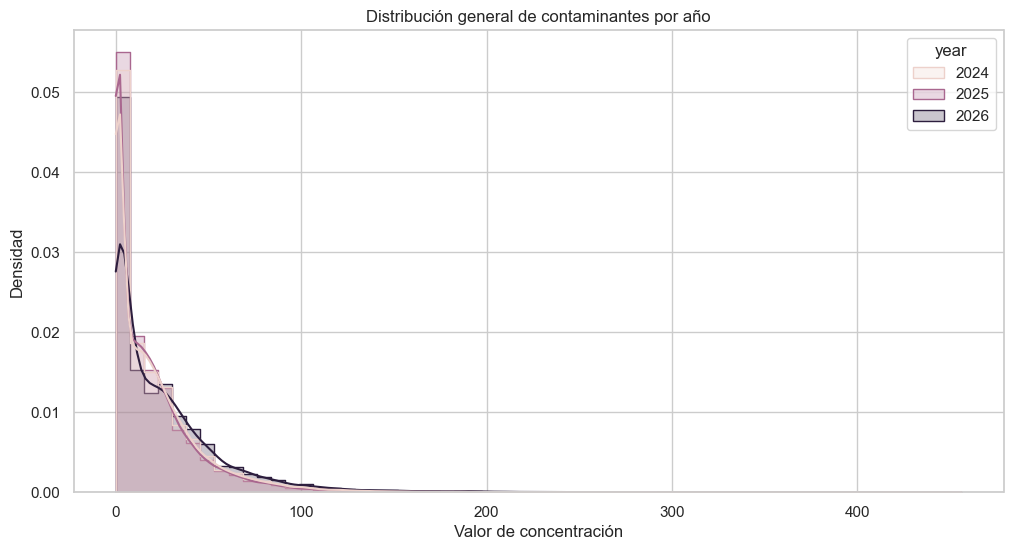

In [21]:
plt.figure(figsize=(12, 6))

sns.histplot(
    data=df_plot_sample,
    x=col_valor,
    hue="year",
    bins=60,
    kde=True,
    element="step",
    stat="density",
    common_norm=False
)

plt.title("Distribución general de contaminantes por año")
plt.xlabel("Valor de concentración")
plt.ylabel("Densidad")
plt.show()

## Distribución Por Contaminante Y Año

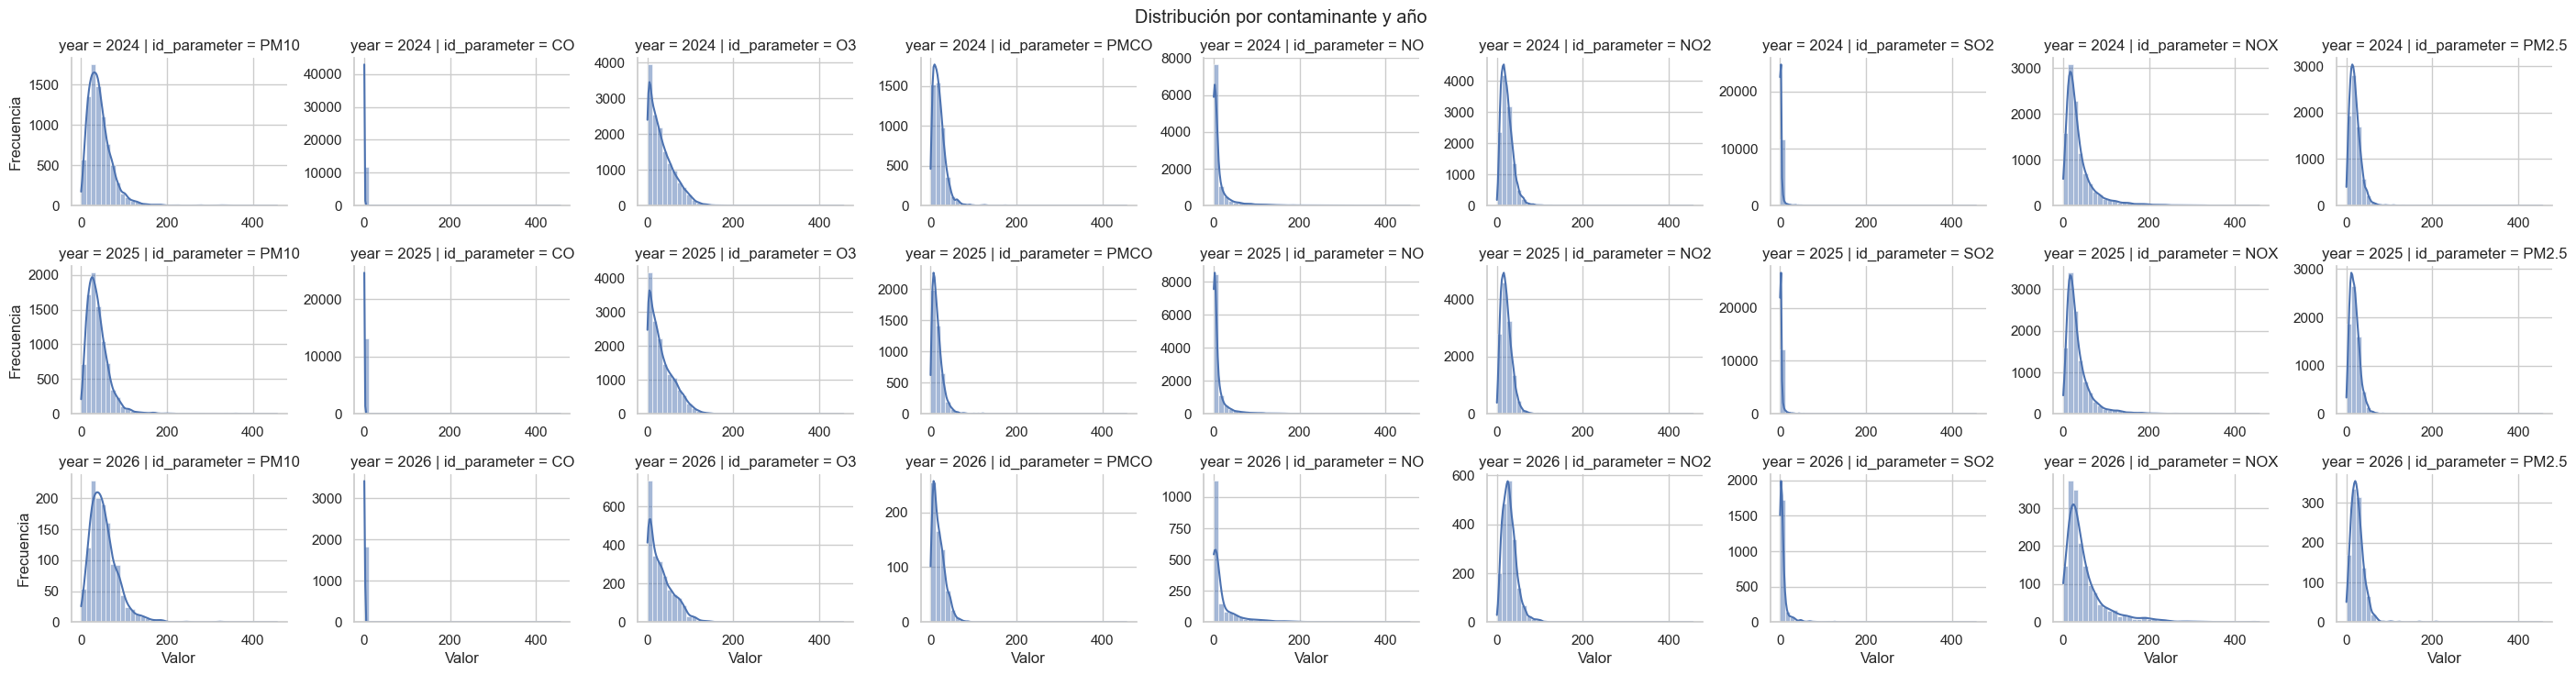

In [22]:
g = sns.displot(
    data=df_plot_sample,
    x=col_valor,
    col="id_parameter",
    row="year",
    bins=40,
    kde=True,
    facet_kws={"sharex": False, "sharey": False},
    height=2.4,
    aspect=1.3
)

g.set_axis_labels("Valor", "Frecuencia")
g.fig.suptitle("Distribución por contaminante y año", y=1.02)
plt.show()

## Boxplot Para Comparar Años

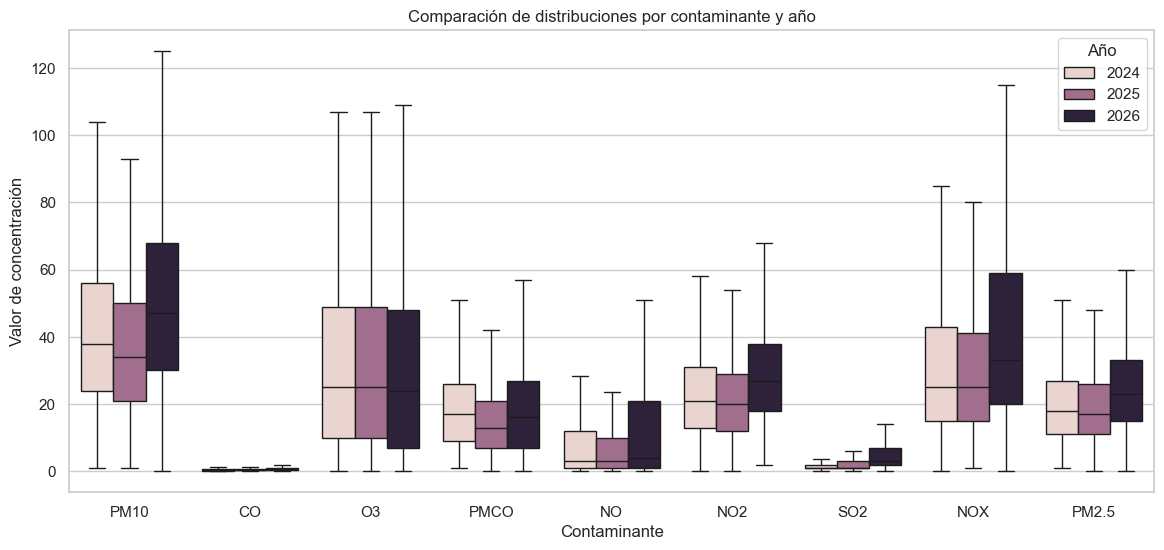

In [23]:
plt.figure(figsize=(14, 6))

sns.boxplot(
    data=df_plot_sample,
    x="id_parameter",
    y=col_valor,
    hue="year",
    showfliers=False
)

plt.title("Comparación de distribuciones por contaminante y año")
plt.xlabel("Contaminante")
plt.ylabel("Valor de concentración")
plt.legend(title="Año")
plt.show()